# Pointer Network — TSP Benchmark

Standard TSP (no time windows, no perturbations).  
Compares the trained **Ptr-Net** against classical baselines.

| Section | Content |
|---------|--------|
| 1 | Imports & model loading |
| 2 | Baseline helpers (NN, 2-opt, brute-force optimal) |
| 3 | Benchmark n=10 — comparison with brute-force optimal |
| 4 | Benchmark n=50, n=100 — comparison with NN baseline |
| 5 | Summary bar chart |
| 6 | Tour visualisation |
| 7 | Model overview figure |

## Section 1 — Imports & model loading

Train first if the checkpoint does not exist:
```bash
python train.py --mode tsp --size medium --n 8 --label optimal --epochs 1000
python train.py --mode tsp --size medium --n 10 --label optimal --epochs 2000 --source tsp --resume model/ptr_net_medium.pt
```

In [14]:
# ── Configuration ─────────────────────────────────────────────────────────────
SIZE       = 'medium'   # 'small' | 'medium' | 'large'
MODEL_PATH = f'model/ptr_net_{SIZE}.pt'

In [15]:
import sys, os, time, glob, re, json as _json
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import permutations

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from data  import random_instance, tour_length, optimal_tour
from model import PointerNetwork, MODEL_SIZES
from train import get_device

DEVICE = get_device()
print(f'Device: {DEVICE}')

SCALE = 200.0   # normalised [0,1]² coords × SCALE = minutes

# ── Dataset discovery ─────────────────────────────────────────────────────────
_HERE        = os.path.dirname(os.path.abspath('__file__'))
DATASETS_DIR = os.path.normpath(os.path.join(_HERE, '..', '..', 'datasets'))

def discover_datasets(datasets_dir=DATASETS_DIR, max_n=None):
    """Return sorted list of (n, path) for all tsptwd_n*.json files."""
    result = []
    for f in sorted(glob.glob(os.path.join(datasets_dir, 'tsptwd_n*.json'))):
        m = re.search(r'tsptwd_n(\d+)\.json$', f)
        if m:
            n = int(m.group(1))
            if max_n is None or n <= max_n:
                result.append((n, f))
    return sorted(result, key=lambda x: x[0])

def load_coords_from_json(path):
    """Load (x, y) from a tsptwd_n*.json — depot at index 0, then clients."""
    with open(path, encoding='utf-8') as fh:
        d = _json.load(fh)
    nodes = [d['depot']] + d['clients']
    return torch.tensor([[v['x'], v['y']] for v in nodes], dtype=torch.float32)

AVAILABLE = discover_datasets()
print(f'Found {len(AVAILABLE)} dataset(s):',
      ', '.join(f'n={n}' for n, _ in AVAILABLE))


Device: cpu
Found 8 dataset(s): n=10, n=50, n=100, n=200, n=300, n=500, n=1000, n=10000


In [16]:
embed, hidden, n_layers = MODEL_SIZES[SIZE]
model = PointerNetwork(embed_dim=embed, hidden_dim=hidden, n_layers=n_layers, node_dim=2).to(DEVICE)

if os.path.exists(MODEL_PATH):
    model.load_state_dict(torch.load(MODEL_PATH, map_location='cpu'))
    model.eval()
    n_params = sum(p.numel() for p in model.parameters())
    print(f'Loaded {SIZE} model from {MODEL_PATH}  ({n_params:,} params)')
else:
    print(f'WARNING: {MODEL_PATH} not found — run train.py first.')
    print('Random weights will be used (results are meaningless).')
    model.eval()

Loaded medium model from model/ptr_net_medium.pt  (922,752 params)


## Section 2 — Baseline helpers

In [17]:
def run_ptr(coords):
    with torch.no_grad():
        _, tour = model(coords.to(DEVICE))
    return tour


## Section 3 — Benchmark n=10 (with brute-force optimal)

For n=10, brute-force optimal is feasible (9! = 362 880 permutations).

In [18]:
n10_entry = next(((n, p) for n, p in AVAILABLE if n == 10), None)
if n10_entry is None:
    raise FileNotFoundError('datasets/tsptwd_n10.json not found.')

coords_10 = load_coords_from_json(n10_entry[1])
print(f'Loaded n=10 dataset: {coords_10.shape[0]} nodes')

opt_tour_10  = optimal_tour(coords_10)
opt_len_10   = tour_length(coords_10, opt_tour_10) * SCALE

t0           = time.perf_counter()
ptr_tour_10  = run_ptr(coords_10)
ptr_time_10  = (time.perf_counter() - t0) * 1000
ptr_len_10   = tour_length(coords_10, ptr_tour_10) * SCALE
gap_10       = (ptr_len_10 / opt_len_10 - 1.0) * 100.0

print(f'n=10  (lengths in minutes)')
print(f'{"Method":<12} {"Length (min)":>14} {"Gap to opt":>12} {"Time (ms)":>12}')
print('-' * 53)
print(f'{"optimal":<12} {opt_len_10:>14.4f} {"-":>12} {"-":>12}')
print(f'{"ptr_net":<12} {ptr_len_10:>14.4f} {gap_10:>+11.1f}% {ptr_time_10:>11.1f}ms')


Loaded n=10 dataset: 11 nodes
n=10  (lengths in minutes)
Method         Length (min)   Gap to opt    Time (ms)
-----------------------------------------------------
optimal            478.7463            -            -
ptr_net            509.1267        +6.3%       101.8ms


## Section 4 — Benchmark n=50, n=100

No brute-force optimal at this scale — gap is reported relative to NN baseline.

In [19]:
all_results = {}   # {n: {'length': float, 'time_ms': float}}

for n, path in AVAILABLE:
    coords   = load_coords_from_json(path)
    actual_n = coords.shape[0]

    t0      = time.perf_counter()
    tour    = run_ptr(coords)
    time_ms = (time.perf_counter() - t0) * 1000
    length  = tour_length(coords, tour) * SCALE   # minutes

    all_results[n] = {'length': length, 'time_ms': time_ms}
    print(f'n={n:<6} ({actual_n} nodes)  Ptr-Net: {length:.4f} min  |  {time_ms:.1f} ms')


n=10     (11 nodes)  Ptr-Net: 509.1267 min  |  20.4 ms
n=50     (51 nodes)  Ptr-Net: 1672.0083 min  |  65.6 ms
n=100    (101 nodes)  Ptr-Net: 2750.3084 min  |  162.4 ms
n=200    (201 nodes)  Ptr-Net: 4232.3586 min  |  213.0 ms
n=300    (301 nodes)  Ptr-Net: 5661.9492 min  |  355.1 ms
n=500    (501 nodes)  Ptr-Net: 8090.7761 min  |  728.0 ms
n=1000   (1001 nodes)  Ptr-Net: 13045.4391 min  |  1581.1 ms
n=10000  (10001 nodes)  Ptr-Net: 83488.2629 min  |  107762.3 ms


## Section 5 — Summary bar chart

KeyError: 'nn'

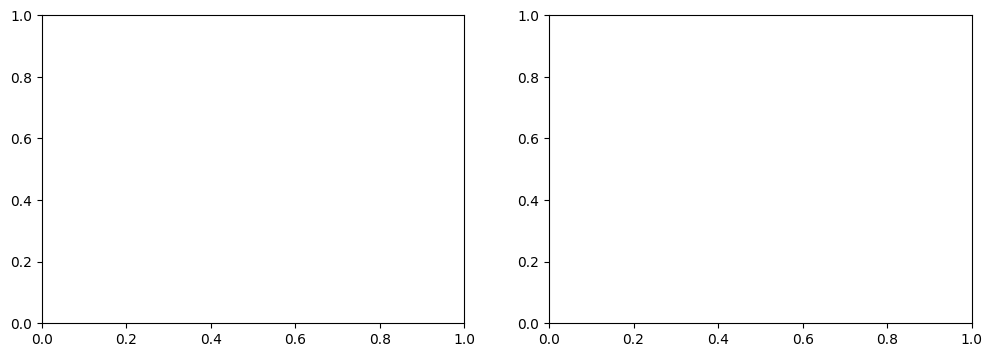

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = {'nn': '#5B9BD5', '2opt': '#ED7D31', 'ptr': '#70AD47', 'ptr_2opt': '#FFC000'}
labels = {'nn': 'NN', '2opt': '2-opt', 'ptr': 'Ptr-Net', 'ptr_2opt': 'Ptr-Net+2opt'}

for ax, N in zip(axes, [50, 100]):
    res    = all_results[N]
    nn_avg = np.mean(res['nn'])
    gaps   = {m: gap(np.mean(res[m]), nn_avg) for m in METHODS_LARGE}

    bars = ax.bar(range(len(METHODS_LARGE)),
                  [gaps[m] for m in METHODS_LARGE],
                  color=[colors[m] for m in METHODS_LARGE],
                  edgecolor='black', linewidth=0.5)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xticks(range(len(METHODS_LARGE)))
    ax.set_xticklabels([labels[m] for m in METHODS_LARGE])
    ax.set_ylabel('Gap % vs NN baseline')
    ax.set_title(f'n={N} — solution quality gap')
    for bar, m in zip(bars, METHODS_LARGE):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.1,
                f'{gaps[m]:.1f}%', ha='center', va='bottom', fontsize=9)

plt.suptitle('Ptr-Net TSP Benchmark — Gap to NN baseline', fontsize=13, fontweight='bold')
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/benchmark_quality.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/benchmark_quality.png')

## Section 6 — Tour visualisation

Visual comparison of all methods on a single n=20 instance.

In [ ]:
coords_viz = random_instance(20, seed=7)
tours = {
    'NN':          run_nn(coords_viz),
    '2-opt':       run_2opt(coords_viz),
    'Ptr-Net':     run_ptr(coords_viz),
    'Ptr+2opt':    run_ptr_2opt(coords_viz),
}

def draw_tour(ax, coords, tour, color, title):
    xy = coords.numpy()
    closed = tour + [tour[0]]
    ax.plot(xy[closed, 0], xy[closed, 1], '-o', color=color,
            markersize=5, linewidth=1.5)
    ax.plot(xy[0, 0], xy[0, 1], 's', color='black', markersize=8, zorder=5)
    length = tour_length(coords, tour)
    ax.set_title(f'{title}\nL={length:.3f}', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

tour_colors = ['#5B9BD5', '#ED7D31', '#70AD47', '#FFC000']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, tour), color in zip(axes, tours.items(), tour_colors):
    draw_tour(ax, coords_viz, tour, color, name)

plt.suptitle('Tour comparison — n=20, seed=7 (black square = start)', fontsize=12)
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/solution_quality_tours.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/solution_quality_tours.png')

## Section 7 — Model overview figure

Four-panel overview on a seed-0, n=8 instance:
1. **NLL training loss curve** — from `model/losses.npy`
2. **Brute-force optimal tour** (green) on the instance
3. **Ptr-Net greedy tour** (blue) with optimality gap
4. **Pointer distribution heatmap** at step 0 (before any selection)

Saves to `figures/demo_overview.png` (referenced in `doc_ptr_net.tex`).

In [ ]:
# ── Section 7: demo_overview.png ──────────────────────────────────────────────
# Requires: model/ptr_net_{SIZE}.pt  (loaded in Section 1)
#           model/losses.npy         (saved automatically by train.py alongside weights)

DEMO_N    = 8
DEMO_SEED = 0

coords_demo = random_instance(DEMO_N, seed=DEMO_SEED)
opt_tour_demo = optimal_tour(coords_demo)
opt_len_demo  = tour_length(coords_demo, opt_tour_demo)

with torch.no_grad():
    log_probs_step0, ptr_tour_demo = model(coords_demo.to(DEVICE))
ptr_len_demo = tour_length(coords_demo, ptr_tour_demo)

# Pointer distribution at step 0 (before any city is visited)
ptr_dist_step0 = torch.exp(log_probs_step0[0]).cpu().numpy()  # (n,)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# (i) Loss curve
ax = axes[0]
losses_path = 'model/losses.npy'
if os.path.exists(losses_path):
    losses_arr = np.load(losses_path)
    ax.plot(losses_arr, linewidth=1.2, color='#2176AE')
    ax.set_xlabel('Step'); ax.set_ylabel('NLL loss'); ax.set_title('(i) Training loss')
else:
    ax.text(0.5, 0.5, 'losses.npy not found\n(run train.py first)',
            ha='center', va='center', transform=ax.transAxes, fontsize=9, color='gray')
    ax.set_title('(i) Training loss'); ax.set_xticks([]); ax.set_yticks([])

# (ii) Optimal tour
ax = axes[1]
xy = coords_demo.numpy()
closed = opt_tour_demo + [opt_tour_demo[0]]
ax.plot(xy[closed, 0], xy[closed, 1], '-o', color='#2CA02C', markersize=6, linewidth=1.8)
ax.plot(xy[0, 0], xy[0, 1], 's', color='black', markersize=10, zorder=5)
ax.set_title(f'(ii) Optimal tour\nL={opt_len_demo:.3f}')
ax.set_xticks([]); ax.set_yticks([])

# (iii) Ptr-Net greedy tour
ax = axes[2]
closed_ptr = ptr_tour_demo + [ptr_tour_demo[0]]
ax.plot(xy[closed_ptr, 0], xy[closed_ptr, 1], '-o', color='#1F77B4', markersize=6, linewidth=1.8)
ax.plot(xy[0, 0], xy[0, 1], 's', color='black', markersize=10, zorder=5)
g_demo = (ptr_len_demo - opt_len_demo) / opt_len_demo * 100
ax.set_title(f'(iii) Ptr-Net tour\nL={ptr_len_demo:.3f}  gap={g_demo:.1f}%')
ax.set_xticks([]); ax.set_yticks([])

# (iv) Pointer distribution at step 0
ax = axes[3]
bars = ax.bar(range(DEMO_N), ptr_dist_step0, color='#FF7F0E', edgecolor='black', linewidth=0.5)
ax.set_xlabel('City index'); ax.set_ylabel('P(point to city i)')
ax.set_title('(iv) Pointer dist. step 0\n(before any selection)')
ax.set_xticks(range(DEMO_N))

plt.suptitle(f'Ptr-Net — Model overview (seed={DEMO_SEED}, n={DEMO_N})', fontsize=13, fontweight='bold')
plt.tight_layout()

os.makedirs('figures', exist_ok=True)
plt.savefig('figures/demo_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/demo_overview.png')